# ZORI ZIP-Code Data Cleaning & Prep

This notebook loads, reshapes, cleans, and enriches Zillow’s Observed Rent Index (ZORI) at the ZIP-code level.
These steps prepare the data for volatility modeling, seasonality analysis, and 3–12-month forecasting in later notebooks.

Primary tasks:

* <b>Load & reshape the wide-format ZORI dataset</b>

* <b>Assess and handle missingness in rent values</b>

* <b>Repair missing ZIP-level metadata (e.g., City)</b>

* <b>Engineer volatility features and export a clean dataset</b>

## 1. Imports & Setup

These packages support data loading (local + GCS), reshaping, visual diagnostics, and USPS ZIP lookup.

In [1]:
import pandas as pd
import numpy as np
import gcsfs
from joblib import Parallel, delayed
import seaborn as sns
import matplotlib.pyplot as plt
from uszipcode import SearchEngine

/opt/anaconda3/lib/python3.13/site-packages/fuzzywuzzy/fuzz.py:11: UserWarning: Using slow pure-python SequenceMatcher. Install python-Levenshtein to remove this warning
  warnings.warn('Using slow pure-python SequenceMatcher. Install python-Levenshtein to remove this warning')


## 2. Load ZORI Data

We load Zillow’s ZIP-level time series directly from Google Cloud Storage. The source data is in wide format (one row per ZIP, one column per month).

In [2]:
fs = gcsfs.GCSFileSystem(project='cse6242-project-476314', token = 'google_default')
with fs.open('cse6242-project-data-bucket/Zip_zori_uc_sfrcondomfr_sm_sa_month.csv') as f:
    zori_wide = pd.read_csv(f, dtype={'RegionName': str})

# use local for initial testing
#zori_wide = pd.read_csv('Zip_zori_uc_sfrcondomfr_sm_sa_month.csv')
#zori_wide

## 3. Reshape Data to Long Format

ZORI distributes months as separate columns.
We “melt” into long format for easier time-series operations.

Time-series forecasting, missingness analysis, and volatility calculations require one row per ZIP × month.

In [3]:
# get into long format
value_vars = [col for col in zori_wide.columns if col[:4].isdigit()]

zori = zori_wide.melt(
    id_vars=['RegionID', 'SizeRank', 'RegionName', 'RegionType', 'StateName', 'State', 'City', 'Metro', 'CountyName'],
    value_vars = value_vars,
    var_name='Date',
    value_name='Rent'
)

# standardize date
zori['Date'] = pd.to_datetime(zori['Date'])
zori['Date'] = zori['Date'].dt.to_period('M').dt.to_timestamp('M')


# rename RegionID to ZIP
zori = zori.rename(columns={'RegionName':'ZIP'})

# sort time series
zori = zori.sort_values(['ZIP', 'Date'])

zori

,RegionID,SizeRank,ZIP,RegionType,StateName,State,City,Metro,CountyName,Date,Rent
3692,58197,3911,01002,zip,MA,MA,Amherst,"Springfield, MA",Hampshire County,2015-01-31,NaN
11545,58197,3911,01002,zip,MA,MA,Amherst,"Springfield, MA",Hampshire County,2015-02-28,NaN
19398,58197,3911,01002,zip,MA,MA,Amherst,"Springfield, MA",Hampshire County,2015-03-31,NaN
27251,58197,3911,01002,zip,MA,MA,Amherst,"Springfield, MA",Hampshire County,2015-04-30,NaN
35104,58197,3911,01002,zip,MA,MA,Amherst,"Springfield, MA",Hampshire County,2015-05-31,NaN
...,...,...,...,...,...,...,...,...,...,...,...
977970,100459,4499,99801,zip,AK,AK,Juneau,"Juneau, AK",Juneau Borough,2025-05-31,2086.647581
985823,100459,4499,99801,zip,AK,AK,Juneau,"Juneau, AK",Juneau Borough,2025-06-30,2106.771773
993676,100459,4499,99801,zip,AK,AK,Juneau,"Juneau, AK",Juneau Borough,2025-07-31,2071.056317
1001529,100459,4499,99801,zip,AK,AK,Juneau,"Juneau, AK",Juneau Borough,2025-08-31,2061.207785


## 4. Inspect Data Structure & Missingness

### 4.1 Basic structure

In [4]:
zori.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1013037 entries, 3692 to 1009382
Data columns (total 11 columns):
 #   Column      Non-Null Count    Dtype         
---  ------      --------------    -----         
 0   RegionID    1013037 non-null  int64         
 1   SizeRank    1013037 non-null  int64         
 2   ZIP         1013037 non-null  object        
 3   RegionType  1013037 non-null  object        
 4   StateName   1013037 non-null  object        
 5   State       1013037 non-null  object        
 6   City        1005555 non-null  object        
 7   Metro       1008006 non-null  object        
 8   CountyName  1013037 non-null  object        
 9   Date        1013037 non-null  datetime64[ns]
 10  Rent        396233 non-null   float64       
dtypes: datetime64[ns](1), float64(1), int64(2), object(7)
memory usage: 92.7+ MB


In [5]:
zori.describe()

,RegionID,SizeRank,Date,Rent
count,1.013037e+06,1.013037e+06,1013037,396233.000000
mean,8.469800e+04,4.770870e+03,2020-05-30 20:39:04.186046720,1814.321472
min,5.819700e+04,1.000000e+00,2015-01-31 00:00:00,528.828904
25%,7.036500e+04,2.037000e+03,2017-09-30 00:00:00,1301.376023
50%,7.948800e+04,4.178000e+03,2020-05-31 00:00:00,1649.037387
75%,9.326100e+04,6.735000e+03,2023-01-31 00:00:00,2128.800125
max,8.459140e+05,3.049000e+04,2025-09-30 00:00:00,99629.555556
std,4.216436e+04,3.566825e+03,NaN,1108.741032


### 4.2 Missing values count

In [6]:
zori.isna().sum()

RegionID           0
SizeRank           0
ZIP                0
RegionType         0
StateName          0
State              0
City            7482
Metro           5031
CountyName         0
Date               0
Rent          616804
dtype: int64

## 5. Missingness Analysis

### 5.1 Detect inconsistent gaps
Check if any ZIPs skip months (should be monthly frequency):

In [7]:
# spacing
zori['gap_days']  = zori.groupby('ZIP')['Date'].diff().dt.days
anomalies = zori[zori['gap_days'] > 31]
anomalies.head()

,RegionID,SizeRank,ZIP,RegionType,StateName,State,City,Metro,CountyName,Date,Rent,gap_days


### 5.2 Standardize the Time Index
We reindex all ZIPs to a complete, uniform timeline:

<b>Jan-2015 through Dec-2024.</b>

This ensures every ZIP has the same number of rows.

In [8]:
full_index = pd.date_range('2015-01-01', '2024-12-01', freq='ME')

zori2 = zori.copy()
zori2['Date'] = pd.to_datetime(zori2['Date']).dt.to_period('M').dt.to_timestamp('M')

zori2 = (
    zori2
    .set_index('Date')
    .groupby('ZIP')
    .apply(lambda x: x.drop(columns='ZIP').reindex(full_index)) 
    .rename_axis(index=['ZIP', 'Date'])
    .reset_index()  
)

zori2

/var/folders/v6/rt7shrqx5sldb75bkwymnhlw0000gp/T/ipykernel_69437/3203717608.py:10: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.drop(columns='ZIP').reindex(full_index))


,ZIP,Date,RegionID,SizeRank,RegionType,StateName,State,City,Metro,CountyName,Rent,gap_days
0,01002,2015-01-31,58197,3911,zip,MA,MA,Amherst,"Springfield, MA",Hampshire County,NaN,NaN
1,01002,2015-02-28,58197,3911,zip,MA,MA,Amherst,"Springfield, MA",Hampshire County,NaN,28.0
2,01002,2015-03-31,58197,3911,zip,MA,MA,Amherst,"Springfield, MA",Hampshire County,NaN,31.0
3,01002,2015-04-30,58197,3911,zip,MA,MA,Amherst,"Springfield, MA",Hampshire County,NaN,30.0
4,01002,2015-05-31,58197,3911,zip,MA,MA,Amherst,"Springfield, MA",Hampshire County,NaN,31.0
...,...,...,...,...,...,...,...,...,...,...,...,...
934502,99801,2024-07-31,100459,4499,zip,AK,AK,Juneau,"Juneau, AK",Juneau Borough,NaN,31.0
934503,99801,2024-08-31,100459,4499,zip,AK,AK,Juneau,"Juneau, AK",Juneau Borough,NaN,31.0
934504,99801,2024-09-30,100459,4499,zip,AK,AK,Juneau,"Juneau, AK",Juneau Borough,NaN,30.0
934505,99801,2024-10-31,100459,4499,zip,AK,AK,Juneau,"Juneau, AK",Juneau Borough,NaN,31.0


### 5.3 Missingness by State and Month

This helps us understand geographic and temporal patterns in missing ZORI values.

In [9]:
zip_missing = (
    zori2.groupby(['State', 'ZIP'])['Rent']
        .apply(lambda s: s.isna().sum())
        .reset_index(name='missing')
)

zip_missing.groupby('State')['missing'].apply(lambda x: (x > 0).mean()).sort_values()

State
NV    0.581395
AZ    0.620321
FL    0.771982
GA    0.810700
VA    0.859223
NY    0.869919
NC    0.874459
TX    0.893408
DC    0.909091
NM    0.921053
CA    0.926045
MA    0.926966
IL    0.928287
ID    0.931818
HI    0.933333
RI    0.939394
CO    0.939560
MD    0.941176
TN    0.945578
WA    0.950226
SC    0.957983
MI    0.961722
OR    0.967480
PA    0.967742
OK    0.970588
IN    0.974684
NJ    0.978166
CT    0.980952
MO    0.981013
AR    0.983051
KS    0.986667
MN    0.992806
OH    0.996154
AK    1.000000
VT    1.000000
WI    1.000000
SD    1.000000
UT    1.000000
MS    1.000000
NE    1.000000
ND    1.000000
MT    1.000000
WV    1.000000
ME    1.000000
LA    1.000000
KY    1.000000
IA    1.000000
DE    1.000000
AL    1.000000
NH    1.000000
WY    1.000000
Name: missing, dtype: float64

### 5.3 Visualize ZIP x Time Missingness

In [10]:
missing_by_month = (
    zori2.groupby('Date')['Rent']
        .apply(lambda s: s.isna().mean())
        .reset_index(name='pct_missing')
)

missing_by_month

,Date,pct_missing
0,2015-01-31,0.895454
1,2015-02-28,0.891761
2,2015-03-31,0.884885
3,2015-04-30,0.883102
4,2015-05-31,0.880810
...,...,...
114,2024-07-31,0.282695
115,2024-08-31,0.281166
116,2024-09-30,0.277601
117,2024-10-31,0.267923


<Axes: xlabel='Date'>

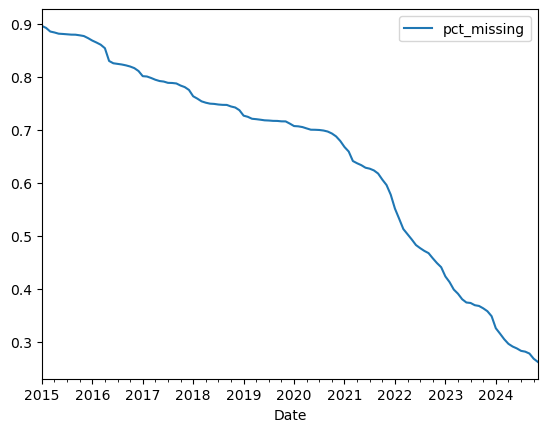

In [11]:
missing_by_month.plot(x='Date', y='pct_missing')

In [12]:
def missing_streak_length(series):
    return series.isna().groupby((~series.isna()).cumsum()).sum().max()

zip_missing_streak = (
    zori2.groupby('ZIP')['Rent']
        .apply(missing_streak_length)
        .reset_index(name='max_missing_streak')
)

zip_missing_streak.sort_values('max_missing_streak', ascending=False).head()

,ZIP,max_missing_streak
3926,48423,119
3643,46036,119
3647,46052,119
3648,46055,119
3651,46064,119


Text(0.5, 1.0, 'Missing Rent Data by ZIP × Month')

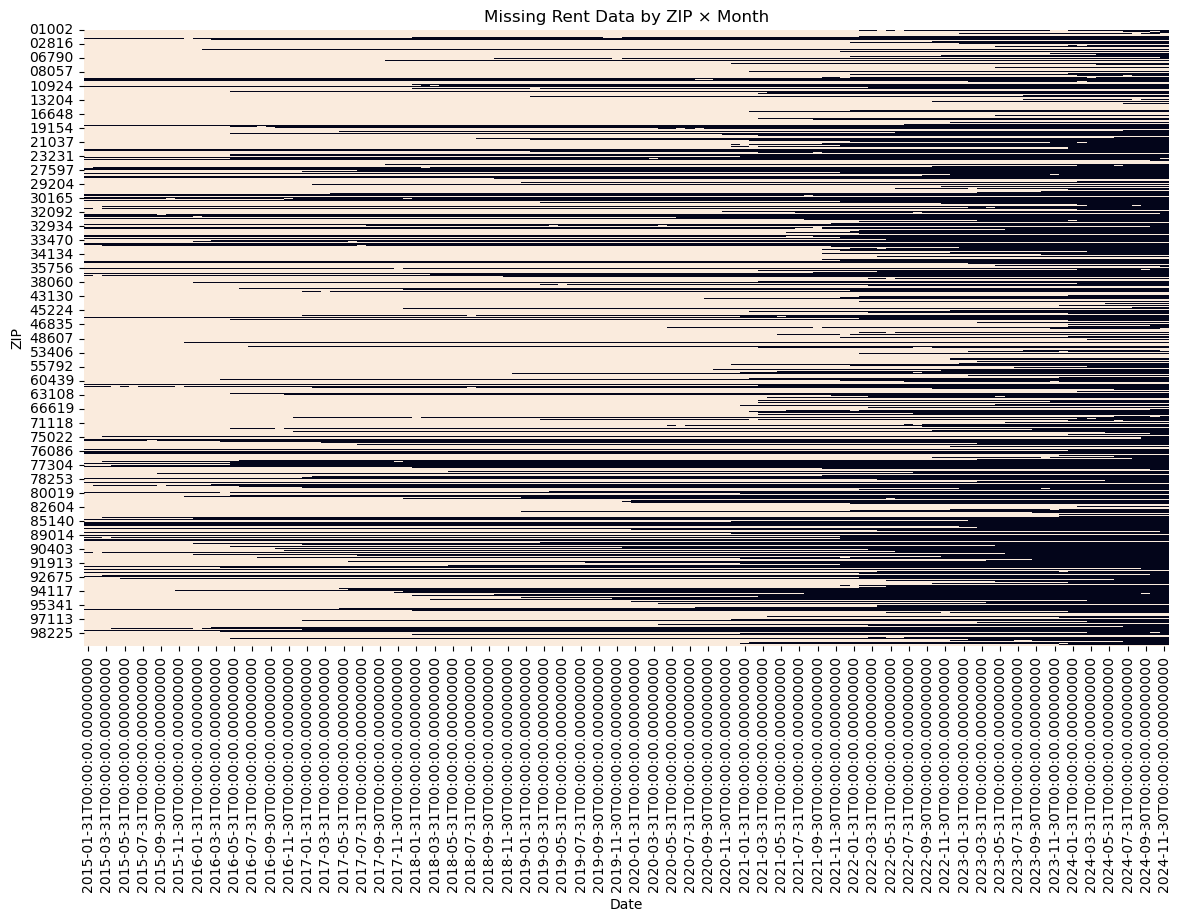

In [13]:
sample = zori2.pivot(index='ZIP', columns='Date', values='Rent')
plt.figure(figsize=(14,8))
sns.heatmap(sample.isna(), cbar=False)
plt.title("Missing Rent Data by ZIP × Month")

## 6. Impute Missing Rent Values

We use linear interpolation within each ZIP.

<b>Why linear interpolation?</b>

* Avoids distortions in seasonal decomposition
* Preserves month-to-month smoothness
* Works well for ZORI, which is already smoothed by Zillow

In [14]:
def interpolate_zip(series):
    s = series.astype(float).copy()

    return s.interpolate(method='linear', limit_direction='both')

Apply per ZIP:

In [15]:
df_interpolated = (
    zori2
        .groupby('ZIP', group_keys=False)
        .apply(lambda g: g.assign(Rent=interpolate_zip(g['Rent'])))
        .reset_index(drop=True)
)

/var/folders/v6/rt7shrqx5sldb75bkwymnhlw0000gp/T/ipykernel_69437/3954869825.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.assign(Rent=interpolate_zip(g['Rent'])))


In [16]:
df_interpolated

,ZIP,Date,RegionID,SizeRank,RegionType,StateName,State,City,Metro,CountyName,Rent,gap_days
0,01002,2015-01-31,58197,3911,zip,MA,MA,Amherst,"Springfield, MA",Hampshire County,2608.712894,NaN
1,01002,2015-02-28,58197,3911,zip,MA,MA,Amherst,"Springfield, MA",Hampshire County,2608.712894,28.0
2,01002,2015-03-31,58197,3911,zip,MA,MA,Amherst,"Springfield, MA",Hampshire County,2608.712894,31.0
3,01002,2015-04-30,58197,3911,zip,MA,MA,Amherst,"Springfield, MA",Hampshire County,2608.712894,30.0
4,01002,2015-05-31,58197,3911,zip,MA,MA,Amherst,"Springfield, MA",Hampshire County,2608.712894,31.0
...,...,...,...,...,...,...,...,...,...,...,...,...
934502,99801,2024-07-31,100459,4499,zip,AK,AK,Juneau,"Juneau, AK",Juneau Borough,NaN,31.0
934503,99801,2024-08-31,100459,4499,zip,AK,AK,Juneau,"Juneau, AK",Juneau Borough,NaN,31.0
934504,99801,2024-09-30,100459,4499,zip,AK,AK,Juneau,"Juneau, AK",Juneau Borough,NaN,30.0
934505,99801,2024-10-31,100459,4499,zip,AK,AK,Juneau,"Juneau, AK",Juneau Borough,NaN,31.0


### 6.1 Identify ZIP Codes with Unreliable Imputation

Compute the longest consecutive missing streak before interpolation:

In [17]:
df_interpolated['missing_after'] = df_interpolated.groupby('ZIP')['Rent'].transform(lambda s: s.isna().sum())

missing_summary = (
    df_interpolated.groupby('ZIP')['Rent']
         .apply(lambda s: s.isna().sum())
         .reset_index(name='missing_count')
)

# How many ZIPs have missing values?
num_zip_with_missing = (missing_summary['missing_count'] > 0).sum()

num_zip_with_missing

np.int64(2020)

In [18]:
# proportion of missing vs total zips
total_zips = missing_summary.shape[0]
percentage = num_zip_with_missing / total_zips * 100
percentage

np.float64(25.72265376289316)

Drop ZIPs with > 24 consecutive missing months.

In [19]:
def longest_gap(s):
    mask = s.isna()
    return mask.groupby((~mask).cumsum()).sum().max()

zip_bad = (
    df_interpolated.groupby('ZIP')['Rent']
                   .apply(longest_gap)
                   .reset_index(name='longest_gap')
)

good_zips = zip_bad[zip_bad['longest_gap'] <= 24]['ZIP']

good_zips.nunique()

5833

In [20]:
df_interpolated_final = df_interpolated[df_interpolated['ZIP'].isin(good_zips)].copy()

## 7. Repair Missing City Names

USPS provides a reliable primary city for each ZIP.

In [21]:
search = SearchEngine()

def get_city(zipcode):
    z = search.by_zipcode(zipcode)
    return z.major_city

In [22]:
# Get the primary city for each ZIP code
df_interpolated_final.loc[:, 'ZIP'] = (
    df_interpolated_final['ZIP']
        .astype(str)
        .str.zfill(5)   # fix any that aren't padded correctly 1002 -> 01002
)

unique_zips = df_interpolated_final['ZIP'].drop_duplicates()

zip_city_map = {
    z: get_city(z) for z in unique_zips
}

df_interpolated_final.loc[:, 'City'] = df_interpolated_final['ZIP'].map(zip_city_map)

In [23]:
df_interpolated_final.isna().sum()

ZIP                 0
Date                0
RegionID            0
SizeRank            0
RegionType          0
StateName           0
State               0
City                0
Metro               0
CountyName          0
Rent                0
gap_days         5833
missing_after       0
dtype: int64

## 8. Feature Engineering

### 8.1 Month-over-month % Change

In [24]:
df_interpolated_final.loc[:, 'pct_change'] = (df_interpolated_final.groupby('ZIP')['Rent'].transform(lambda s: s.pct_change()))

### 8.2 Rolling 12-month Volatility

This is the standard deviation of percent changes.

In [25]:
df_interpolated_final.loc[:, 'Volatility'] = (df_interpolated_final.groupby('ZIP')['pct_change'].transform(lambda s: s.rolling(12, min_periods=6).std()))

## 9. Final Cleaning and Export

In [26]:
df_final = df_interpolated_final.copy()
df_final.info()

<class 'pandas.core.frame.DataFrame'>
Index: 694127 entries, 0 to 934268
Data columns (total 15 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   ZIP            694127 non-null  object        
 1   Date           694127 non-null  datetime64[ns]
 2   RegionID       694127 non-null  int64         
 3   SizeRank       694127 non-null  int64         
 4   RegionType     694127 non-null  object        
 5   StateName      694127 non-null  object        
 6   State          694127 non-null  object        
 7   City           694127 non-null  object        
 8   Metro          694127 non-null  object        
 9   CountyName     694127 non-null  object        
 10  Rent           694127 non-null  float64       
 11  gap_days       688294 non-null  float64       
 12  missing_after  694127 non-null  int64         
 13  pct_change     688294 non-null  float64       
 14  Volatility     659129 non-null  float64       
dtypes: da

Drop intermediate columns:

In [27]:
cols_to_drop = ['StateName', 'gap_days', 'missing_after', 'pct_change']
df_final = df_final.drop(columns=cols_to_drop)
df_final.head()

,ZIP,Date,RegionID,SizeRank,RegionType,State,City,Metro,CountyName,Rent,Volatility
0,01002,2015-01-31,58197,3911,zip,MA,Amherst,"Springfield, MA",Hampshire County,2608.712894,NaN
1,01002,2015-02-28,58197,3911,zip,MA,Amherst,"Springfield, MA",Hampshire County,2608.712894,NaN
2,01002,2015-03-31,58197,3911,zip,MA,Amherst,"Springfield, MA",Hampshire County,2608.712894,NaN
3,01002,2015-04-30,58197,3911,zip,MA,Amherst,"Springfield, MA",Hampshire County,2608.712894,NaN
4,01002,2015-05-31,58197,3911,zip,MA,Amherst,"Springfield, MA",Hampshire County,2608.712894,NaN


Export:

In [28]:
df_final.to_csv('clean_zori.csv', index=False)
df_final.to_parquet('clean_zori.parquet', index=False, compression='snappy')